# 05 — Comparative Analysis: Germany vs Netherlands

Compare motorway accident safety between:
- 🇩🇪 **Unlimited Autobahn** (no speed limit sections)
- 🇩🇪 **Speed-limited Autobahn** (100/120/130 km/h limit)
- 🇳🇱 **Dutch motorways** (autosnelwegen, 100/130 km/h)

Main metric: **fatalities per 1000 accidents** (severity index).
With vehicle-km normalisation where available.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sys.path.insert(0, "../src")


DATA_RAW = Path("../data/raw")
DATA_PROC = Path("../data/processed")
sns.set_theme(style="whitegrid")
print("Ready.")

Ready.


## 1. Load processed data from notebooks 03 and 04

In [ ]:
classified_path = DATA_PROC / "unfallatlas_classified.parquet"
if classified_path.exists():
    df_de = pd.read_parquet(classified_path)
    print(f"Germany: {len(df_de):,} accident records")
else:
    print("Run notebook 03 first.")
    df_de = None

nl_path = DATA_PROC / "rws_motorway_annual.parquet"
if nl_path.exists():
    df_nl_annual = pd.read_parquet(nl_path)
    print(f"Netherlands: {len(df_nl_annual)} years")
else:
    print("Run notebook 04 first.")
    df_nl_annual = None

# Destatis long-term data
from autobahn_safety.data_loaders import load_destatis_autobahn
destatis_path = DATA_RAW / "germany" / "destatis" / "destatis_verkehrsunfaelle_zeitreihen.xlsx"
if destatis_path.exists():
    df_destatis = load_destatis_autobahn(destatis_path)
    print(f"Destatis: {len(df_destatis)} years")
else:
    print("Destatis Excel not found.")
    df_destatis = None


## 2. Severity index comparison (fatalities per 1000 accidents)

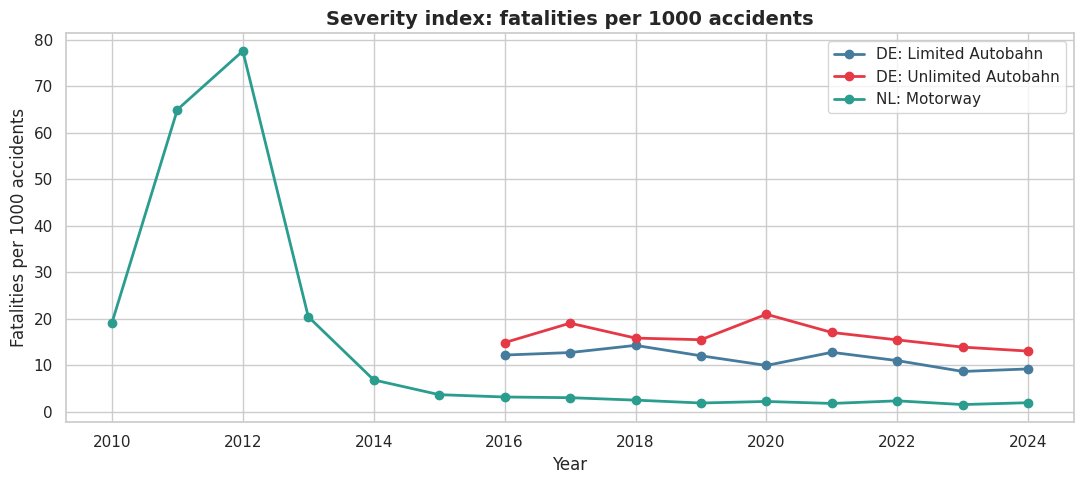

In [3]:
if df_de is not None:
    de_groups = {
        "DE: Unlimited Autobahn": df_de[df_de["on_unlimited"]],
        "DE: Limited Autobahn": df_de[df_de["on_limited_mw"]],
    }
    de_annual = []
    for label, grp in de_groups.items():
        by_year = (
            grp.groupby("year")
            .agg(
                total=("severity", "count"),
                fatal=("severity", lambda x: (x == "fatal").sum()),
            )
            .reset_index()
        )
        by_year["group"] = label
        by_year["severity_idx"] = by_year["fatal"] / by_year["total"]
        de_annual.append(by_year)
    df_de_annual = pd.concat(de_annual)

    if df_nl_annual is not None:
        df_nl_plot = df_nl_annual[["year", "total", "fatal", "severity_idx"]].copy()
        df_nl_plot["group"] = "NL: Motorway"
        df_combined = pd.concat([df_de_annual, df_nl_plot], ignore_index=True)

        palette = {
            "DE: Unlimited Autobahn": "#e63946",
            "DE: Limited Autobahn": "#457b9d",
            "NL: Motorway": "#2a9d8f",
        }
        fig, ax = plt.subplots(figsize=(11, 5))
        for grp_name, grp in df_combined.groupby("group"):
            ax.plot(
                grp["year"],
                grp["severity_idx"] * 1000,
                marker="o",
                label=grp_name,
                linewidth=2,
                color=palette.get(grp_name, "grey"),
            )
        ax.set_title(
            "Severity index: fatalities per 1000 accidents", fontsize=14, fontweight="bold"
        )
        ax.set_xlabel("Year")
        ax.set_ylabel("Fatalities per 1000 accidents")
        ax.legend()
        plt.tight_layout()
        plt.show()

## 3. Statistical comparison: unlimited vs limited Autobahn

In [4]:
if df_de is not None:
    years = sorted(df_de["year"].unique())
    results = []
    for yr in years:
        yr_data = df_de[df_de["year"] == yr]
        n_unl = (yr_data["on_unlimited"] & (yr_data["severity"] == "fatal")).sum()
        n_lim = (yr_data["on_limited_mw"] & (yr_data["severity"] == "fatal")).sum()
        tot_unl = yr_data["on_unlimited"].sum()
        tot_lim = yr_data["on_limited_mw"].sum()
        if tot_unl > 0 and tot_lim > 0:
            results.append(
                {
                    "year": yr,
                    "fatal_rate_unlimited": n_unl / tot_unl * 1000,
                    "fatal_rate_limited": n_lim / tot_lim * 1000,
                    "rate_ratio": (n_unl / tot_unl) / (n_lim / tot_lim) if n_lim > 0 else np.nan,
                    "n_fatal_unlimited": n_unl,
                    "n_fatal_limited": n_lim,
                }
            )

    df_results = pd.DataFrame(results)
    print("Fatality rate (per 1000 accidents) — unlimited vs limited Autobahn:")
    print(df_results.to_string(index=False, float_format="{:.3f}".format))

Fatality rate (per 1000 accidents) — unlimited vs limited Autobahn:
 year  fatal_rate_unlimited  fatal_rate_limited  rate_ratio  n_fatal_unlimited  n_fatal_limited
 2016                14.859              12.186       1.219                113               62
 2017                19.046              12.724       1.497                174               81
 2018                15.833              14.267       1.110                146              100
 2019                15.485              12.028       1.287                188              110
 2020                20.957               9.952       2.106                204               68
 2021                17.044              12.776       1.334                176               93
 2022                15.443              10.993       1.405                170               88
 2023                13.894               8.663       1.604                164               75
 2024                13.040               9.206       1.417         

In [5]:
if "df_results" in locals() and len(df_results):
    total_unl_fatal = df_results["n_fatal_unlimited"].sum()
    total_lim_fatal = df_results["n_fatal_limited"].sum()
    total_unl_acc = df_de[df_de["on_unlimited"]].shape[0]
    total_lim_acc = df_de[df_de["on_limited_mw"]].shape[0]

    rate_unl = total_unl_fatal / total_unl_acc * 1000
    rate_lim = total_lim_fatal / total_lim_acc * 1000

    result = stats.poisson_means_test(
        total_unl_fatal, total_unl_acc, total_lim_fatal, total_lim_acc
    )

    print("Fatality rate (per 1000 accidents):")
    print(f"  Unlimited Autobahn : {rate_unl:.3f}")
    print(f"  Limited Autobahn   : {rate_lim:.3f}")
    print(f"  Rate ratio         : {rate_unl/rate_lim:.3f}")
    print(f"  Poisson p-value    : {result.pvalue:.4f}")
    sig = "SIGNIFICANT" if result.pvalue < 0.05 else "NOT significant"
    print(f"=> Difference is {sig} (alpha=0.05)")

Fatality rate (per 1000 accidents):
  Unlimited Autobahn : 16.040
  Limited Autobahn   : 11.283
  Rate ratio         : 1.422
  Poisson p-value    : 0.0000
=> Difference is SIGNIFICANT (alpha=0.05)


## 4. Summary bar chart

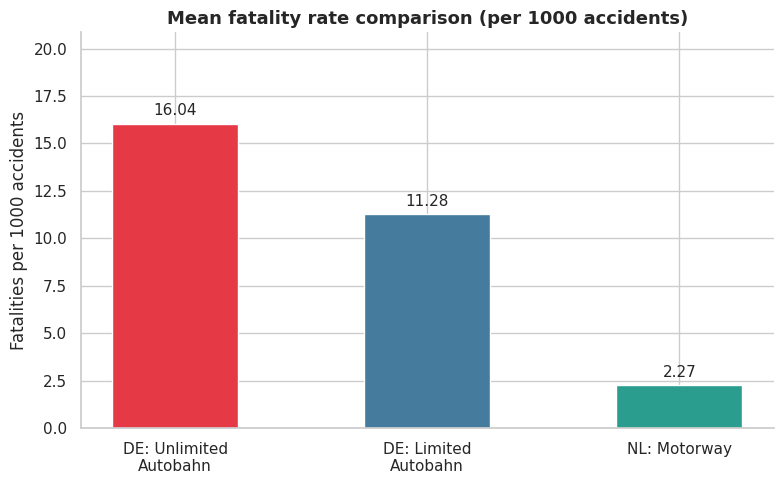

In [6]:
if df_de is not None and df_nl_annual is not None:
    common_years = set(df_de["year"].unique()) & set(df_nl_annual["year"].unique())

    means = {
        "DE: Unlimited\nAutobahn": (
            df_de[df_de["on_unlimited"] & df_de["year"].isin(common_years)]["severity"] == "fatal"
        ).mean()
        * 1000,
        "DE: Limited\nAutobahn": (
            df_de[df_de["on_limited_mw"] & df_de["year"].isin(common_years)]["severity"] == "fatal"
        ).mean()
        * 1000,
        "NL: Motorway": df_nl_annual[df_nl_annual["year"].isin(common_years)]["severity_idx"].mean()
        * 1000,
    }

    colors = ["#e63946", "#457b9d", "#2a9d8f"]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        list(means.keys()), list(means.values()), color=colors, width=0.5, edgecolor="white"
    )
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=11)
    ax.set_title(
        "Mean fatality rate comparison (per 1000 accidents)", fontsize=13, fontweight="bold"
    )
    ax.set_ylabel("Fatalities per 1000 accidents")
    ax.set_ylim(0, max(means.values()) * 1.3)
    sns.despine()
    plt.tight_layout()
    plt.show()

## 5. Methodology notes

- **DE motorway classification:** spatial join with OSM (50m buffer). Unlimited = no `maxspeed` tag or `maxspeed=DE:motorway`.
- **NL motorway classification:** `MAXSNELHD ∈ {100, 120, 130}` + `BEBKOM == 'BU'` from BRON.
- **Rate metric:** fatalities per 1000 accidents. Ideal metric would be per billion vehicle-km but NL vehicle-km by road type is not fully available for the overlap period.
- **Limitations:** GPS accuracy, OSM completeness, different police reporting thresholds between DE and NL.

## 6. Motorway fatalities per million inhabitants per year

**Metric:** motorway deaths per million inhabitants, using population as a
standardised exposure proxy. This avoids the network-length bias: NL has 2,758 km
of very busy motorways while DE has 16,441 km of unlimited-speed sections including
lightly-trafficked rural routes. Deaths are universally recorded regardless of
recording threshold, making this a robust cross-country comparison.

Population constants (hardcoded):
- Germany: 83.2 million (2020 census average)
- Netherlands: 17.6 million (2020 CBS average)

**DE source:** Destatis `destatis_verkehrsunfaelle_zeitreihen.xlsx` → `accidents_fatal`
(whole Autobahn network)

**NL source:** CBS `deaths_by_mode.csv` filtered to motorway mode (A048748),
total population (T001038), all ages (10000) → `Verkeersdoden_1`

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")

OUTPUT_FIG = Path("../output/figures")
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)

# Population constants (source: Germany 2020 census average; Netherlands 2020 CBS average)
POP_DE_M = 83.2   # Germany population in millions
POP_NL_M = 17.6   # Netherlands population in millions

# ── DE: Destatis Autobahn fatal accidents ─────────────────────────────────
if df_destatis is not None:
    de_data = df_destatis[df_destatis["year"].between(2016, 2021)][["year", "accidents_fatal"]].copy()
    de_data["deaths_per_mio"] = de_data["accidents_fatal"] / POP_DE_M
else:
    de_data = pd.DataFrame(columns=["year", "accidents_fatal", "deaths_per_mio"])

# ── NL: CBS deaths by mode — motorway (A048748), total sex (T001038), all ages (10000) ──
cbs_path = Path("../data/raw/netherlands/cbs/deaths_by_mode.csv")
df_cbs = pd.read_csv(cbs_path, sep=",")
df_cbs["year"] = df_cbs["Perioden"].str[:4].astype(int)
nl_raw = df_cbs[
    (df_cbs["Geslacht"].str.strip() == "T001038")
    & (df_cbs["Leeftijd"] == 10000)
    & (df_cbs["WijzeVanDeelname"].str.strip() == "A048748")
].copy()
nl_data = nl_raw[nl_raw["year"].between(2016, 2021)][["year", "Verkeersdoden_1"]].copy()
nl_data = nl_data.rename(columns={"Verkeersdoden_1": "deaths"})
nl_data["deaths_per_mio"] = nl_data["deaths"] / POP_NL_M

# ── print summary table ───────────────────────────────────────────────────
print("=== Motorway fatalities per million inhabitants ===\n")
print(f"{'Year':>6}  {'DE deaths':>10}  {'DE/mio':>8}  {'NL deaths':>10}  {'NL/mio':>8}")
print("-" * 52)
merged7 = de_data.merge(nl_data, on="year", suffixes=("_de", "_nl"))
for _, row in merged7.iterrows():
    print(f"  {int(row['year']):>4}  {int(row['accidents_fatal']):>10}  "
          f"{row['deaths_per_mio_de']:>8.2f}  "
          f"{int(row['deaths']):>10}  {row['deaths_per_mio_nl']:>8.2f}")

# ── plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(de_data["year"], de_data["deaths_per_mio"],
        marker="s", color="#e63946", linewidth=2.5, label="Germany (Autobahn)")
ax.plot(nl_data["year"], nl_data["deaths_per_mio"],
        marker="o", color="#2a9d8f", linewidth=2.5, label="Netherlands (motorway)")

for _, row in de_data.iterrows():
    ax.annotate(f"{row['deaths_per_mio']:.1f}",
                xy=(row["year"], row["deaths_per_mio"]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=9, color="#e63946")
for _, row in nl_data.iterrows():
    ax.annotate(f"{row['deaths_per_mio']:.1f}",
                xy=(row["year"], row["deaths_per_mio"]),
                xytext=(0, -16), textcoords="offset points",
                ha="center", fontsize=9, color="#2a9d8f")

ax.set_title("Motorway fatalities per million inhabitants: Germany vs Netherlands",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Motorway deaths per million inhabitants")
ax.set_xticks(sorted(merged7["year"].unique()))
ax.legend(fontsize=11)
ax.set_ylim(bottom=0)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_FIG / "fig07_motorway_deaths_per_capita.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig07_motorway_deaths_per_capita.png")


## 7. Accident density — all accidents per 100 km (Germany only)

**Goal:** Disentangle *frequency* from *severity*. Are there simply more accidents on
unlimited sections, or do the same number of crashes just have more lethal outcomes?

We restrict this to Germany only, where both road types are captured by the same
Unfallatlas survey methodology, making the comparison internally consistent.

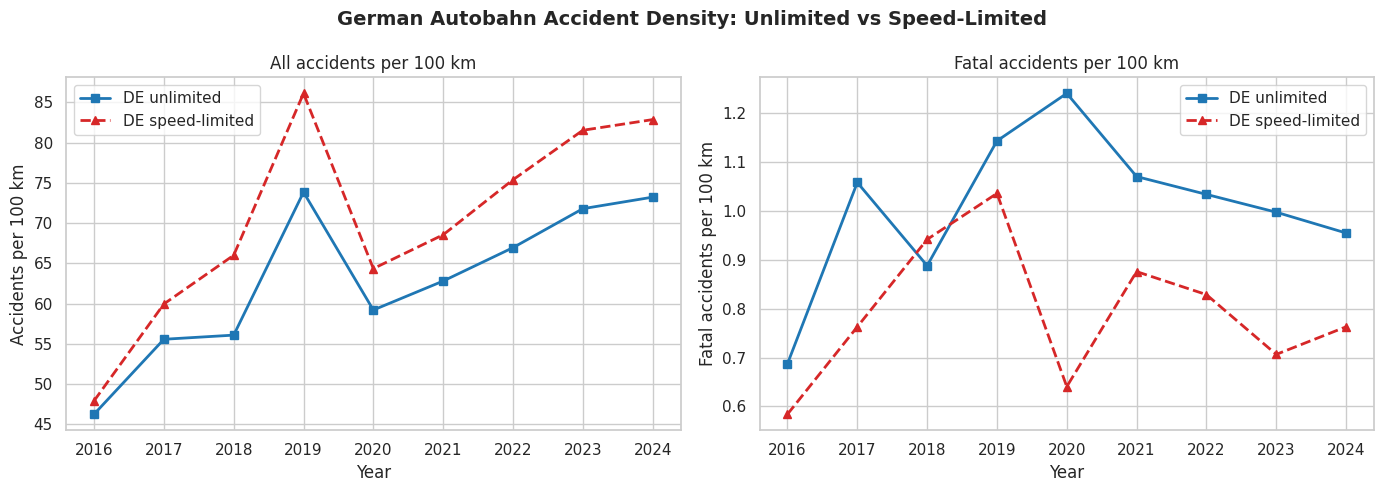

Saved fig08_accident_density_de.png

=== DE accident density (accidents per 100 km / year) ===
 year  total/100km_unl  total/100km_lim  fatal/100km_unl  fatal/100km_lim
 2016           46.256           47.919            0.687            0.584
 2017           55.568           59.955            1.058            0.763
 2018           56.085           66.011            0.888            0.942
 2019           73.846           86.127            1.143            1.036
 2020           59.206           64.353            1.241            0.640
 2021           62.806           68.553            1.070            0.876
 2022           66.955           75.391            1.034            0.829
 2023           71.796           81.541            0.998            0.706
 2024           73.232           82.869            0.955            0.763


In [8]:
if df_de is not None:
    de_mw = df_de[df_de["on_motorway"]]
    de_unl_all = de_mw[de_mw["on_unlimited"]].groupby("year").size().rename("total_unl")
    de_lim_all = de_mw[de_mw["on_limited_mw"]].groupby("year").size().rename("total_lim")
    de_unl_fat = (
        de_mw[de_mw["on_unlimited"] & (de_mw["severity"] == "fatal")]
        .groupby("year").size().rename("fatal_unl")
    )
    de_lim_fat = (
        de_mw[de_mw["on_limited_mw"] & (de_mw["severity"] == "fatal")]
        .groupby("year").size().rename("fatal_lim")
    )

    df7 = pd.concat([de_unl_all, de_lim_all, de_unl_fat, de_lim_fat], axis=1).reset_index()
    df7["total_density_unl"] = df7["total_unl"] / KM_DE_UNLIMITED * 100
    df7["total_density_lim"] = df7["total_lim"] / KM_DE_LIMITED   * 100
    df7["fatal_density_unl"] = df7["fatal_unl"] / KM_DE_UNLIMITED * 100
    df7["fatal_density_lim"] = df7["fatal_lim"] / KM_DE_LIMITED   * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    # Left: total accidents per 100 km
    ax = axes[0]
    ax.plot(df7["year"], df7["total_density_unl"], marker="s", color="tab:blue",
            label="DE unlimited", linewidth=2)
    ax.plot(df7["year"], df7["total_density_lim"], marker="^", color="tab:red",
            label="DE speed-limited", linewidth=2, linestyle="--")
    ax.set_title("All accidents per 100 km", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Accidents per 100 km")
    ax.legend()

    # Right: fatal accidents per 100 km
    ax2 = axes[1]
    ax2.plot(df7["year"], df7["fatal_density_unl"], marker="s", color="tab:blue",
             label="DE unlimited", linewidth=2)
    ax2.plot(df7["year"], df7["fatal_density_lim"], marker="^", color="tab:red",
             label="DE speed-limited", linewidth=2, linestyle="--")
    ax2.set_title("Fatal accidents per 100 km", fontsize=12)
    ax2.set_xlabel("Year")
    ax2.set_ylabel("Fatal accidents per 100 km")
    ax2.legend()

    fig.suptitle("German Autobahn Accident Density: Unlimited vs Speed-Limited",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG / "fig08_accident_density_de.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fig08_accident_density_de.png")

    print("\n=== DE accident density (accidents per 100 km / year) ===")
    print(df7[["year", "total_density_unl", "total_density_lim",
               "fatal_density_unl", "fatal_density_lim"]]
          .rename(columns={
              "total_density_unl": "total/100km_unl",
              "total_density_lim": "total/100km_lim",
              "fatal_density_unl": "fatal/100km_unl",
              "fatal_density_lim": "fatal/100km_lim",
          })
          .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("DE data not available.")

## 8. Injury severity pyramid (fatal : serious : slight ratios)

**Goal:** High-speed crashes convert kinetic energy into more severe injuries.
Comparing the *shape* of the injury pyramid (% fatal vs % serious vs % slight)
reflects this physics regardless of how many minor incidents are recorded — making
it the most robust cross-country metric.

**Denominator:** injury accidents only — `fatal + serious + slight` — excluding
property-damage-only (`material`) accidents. This ensures each group sums to exactly
100% and is comparable to German injury-accident data which excludes property-damage-only.

**Data note:** The Dutch BRON dataset (`rws_motorway_annual.parquet`) does not
separately record serious/slight injury accidents on motorways (serious=0, slight=0
throughout the dataset). The NL pyramid therefore shows 100% fatal among recorded
injury accidents — a limitation of the source data, not the analysis.

In [ ]:
# ── German pooled (2016–2024) ──────────────────────────────────────────────────
if df_de is not None:
    de_mw = df_de[df_de["on_motorway"] & df_de["year"].between(2016, 2024)]

    def pyramid_counts(sub_df):
        counts = sub_df["severity"].value_counts()
        fatal   = int(counts.get("fatal",         0))
        serious = int(counts.get("serious_injury", 0))
        slight  = int(counts.get("slight_injury",  0))
        total   = fatal + serious + slight
        if total == 0:
            return dict(fatal=0, serious=0, slight=0,
                        pct_fatal=0, pct_serious=0, pct_slight=0, total=0)
        return dict(
            fatal=fatal, serious=serious, slight=slight,
            pct_fatal  = fatal   / total * 100,
            pct_serious= serious / total * 100,
            pct_slight = slight  / total * 100,
            total=total,
        )

    de_unl_pyr = pyramid_counts(de_mw[de_mw["on_unlimited"]])
    de_lim_pyr = pyramid_counts(de_mw[de_mw["on_limited_mw"]])

    # ── NL pooled (2016–2024): use fatal+serious+slight as denominator ─────
    # Excludes material (property-damage-only) to match DE injury-accident data.
    # Note: serious=0 and slight=0 in rws_motorway_annual.parquet — NL BRON does
    # not separately record serious/slight on motorways → NL pyramid = 100% fatal.
    nl_pyr = None
    if df_nl_annual is not None:
        nl_sub       = df_nl_annual[df_nl_annual["year"].between(2016, 2024)]
        nl_fatal_n   = int(nl_sub["fatal"].sum())
        nl_serious_n = int(nl_sub["serious"].sum())
        nl_slight_n  = int(nl_sub["slight"].sum())
        nl_total_n   = nl_fatal_n + nl_serious_n + nl_slight_n
        if nl_total_n > 0:
            nl_pyr = dict(
                fatal=nl_fatal_n, serious=nl_serious_n, slight=nl_slight_n,
                total=nl_total_n,
                pct_fatal   = nl_fatal_n   / nl_total_n * 100,
                pct_serious = nl_serious_n / nl_total_n * 100,
                pct_slight  = nl_slight_n  / nl_total_n * 100,
            )

    # ── print summary table (verify each row sums to 100%) ─────────────────
    print("=== Injury severity pyramid (2016–2024 pooled) ===\n")
    print(f"{'Group':<28} {'Fatal':>8} {'Serious':>8} {'Slight':>8} {'Total':>8}  "
          f"{'%Fatal':>7} {'%Serious':>8} {'%Slight':>8}  {'Sum%':>6}")
    print("-" * 100)
    for label, d in [("DE unlimited Autobahn", de_unl_pyr),
                     ("DE speed-limited Autobahn", de_lim_pyr)]:
        row_sum = d["pct_fatal"] + d["pct_serious"] + d["pct_slight"]
        print(f"{label:<28} {d['fatal']:>8,} {d['serious']:>8,} {d['slight']:>8,} "
              f"{d['total']:>8,}  {d['pct_fatal']:>6.2f}% {d['pct_serious']:>7.2f}% "
              f"{d['pct_slight']:>7.2f}%  {row_sum:>5.1f}%")
    if nl_pyr:
        row_sum = nl_pyr["pct_fatal"] + nl_pyr["pct_serious"] + nl_pyr["pct_slight"]
        print(f"{'NL (injury accidents only)':<28} {nl_pyr['fatal']:>8,} "
              f"{nl_pyr['serious']:>8,} {nl_pyr['slight']:>8,} {nl_pyr['total']:>8,}  "
              f"{nl_pyr['pct_fatal']:>6.2f}% {nl_pyr['pct_serious']:>7.2f}% "
              f"{nl_pyr['pct_slight']:>7.2f}%  {row_sum:>5.1f}%")
        print("\nNote: NL BRON does not separately record serious/slight injuries on motorways.")
        print("      serious=0, slight=0 → NL pyramid shows 100% fatal.")

    # ── plot — unified 3-group pyramid ────────────────────────────────────
    groups   = ["DE unlimited", "DE speed-limited", "NL motorway"]
    pyrs     = [de_unl_pyr, de_lim_pyr,
                nl_pyr if nl_pyr else dict(pct_fatal=0.0, pct_serious=0.0, pct_slight=0.0)]
    pct_fatal  = [p["pct_fatal"]   for p in pyrs]
    pct_ser    = [p["pct_serious"] for p in pyrs]
    pct_sli    = [p["pct_slight"]  for p in pyrs]
    y_pos = np.arange(len(groups))
    bar_h = 0.55

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(y_pos, pct_fatal, bar_h, label="Fatal",   color="#d62728")
    ax.barh(y_pos, pct_ser,   bar_h, left=pct_fatal,  label="Serious", color="#ff7f0e")
    ax.barh(y_pos, pct_sli,   bar_h,
            left=[a+b for a,b in zip(pct_fatal, pct_ser)],
            label="Slight", color="#aec7e8")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(groups, fontsize=12)
    ax.set_xlabel("Share of injury accidents (%)", fontsize=11)
    ax.set_xlim(0, 100)
    ax.set_title(
        "Injury Severity Pyramid (2016–2024 pooled)\n"
        "Denominator: injury accidents only (fatal + serious + slight; excludes property-damage-only)",
        fontsize=12, fontweight="bold",
    )
    ax.legend(loc="lower right", fontsize=10)

    for i, (f, s, sl) in enumerate(zip(pct_fatal, pct_ser, pct_sli)):
        if f > 0.5:
            ax.text(f/2, i, f"{f:.1f}%", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
        if s > 1:
            ax.text(f+s/2, i, f"{s:.1f}%", ha="center", va="center",
                    fontsize=9, color="white")
        if sl > 1:
            ax.text(f+s+sl/2, i, f"{sl:.1f}%", ha="center", va="center",
                    fontsize=9, color="black")

    if nl_pyr and nl_pyr["pct_slight"] == 0.0:
        ax.annotate(
            "NL: serious/slight\nnot recorded separately",
            xy=(50, 2), ha="center", va="center",
            fontsize=8, color="#555555", style="italic",
        )

    sns.despine()
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG / "fig09_injury_pyramid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nSaved fig09_injury_pyramid.png")
else:
    print("DE data not available.")
